**Statistical Learning History**

Statistical learning began with least squares linear regression which was developed at the beginning of the nineteenth century with the publication of "Nouvelles Methodes Pour La Determination Des Orbites Des Cometes" (English: New Methods for the Determination of Orbits of Comets) by Par A.M. Legendre.

By the 1970s general linear models developed to describe an entire class of statistical learning methods that include both linear and logistic regression.

Non-linear methods proved elusive computationally but by the 1980s computing technology finally improved enough so that non-linear methods were no longer computationally infeasible.

After 1980 a wide corpous of methods have emerged including classification trees, regression trees, generalized additive models, neural networks, and support vector machines.

Statistical learning today has emerged as a new subfield in statistics focused on supervised and unsupervised modeling and prediction.

Here we apply these methods to financial data.

In [24]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [10]:
ticker = "NVDA"
start_date = "2020-01-01"
end_date = "2024-01-01"

# Download data
finance_data = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [11]:
finance_data.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-12-22,49.195000,49.382999,48.466999,48.830002,48.823704,252507000
2023-12-26,48.967999,49.599998,48.959999,49.278999,49.272640,244200000
2023-12-27,49.511002,49.680000,49.084999,49.417000,49.410622,233648000
2023-12-28,49.643002,49.883999,49.411999,49.521999,49.515610,246587000
2023-12-29,49.813000,49.997002,48.750999,49.521999,49.515610,389293000


In [12]:
finance_data['Volume']

Date
2020-01-02    237536000
2020-01-03    205384000
2020-01-06    262636000
2020-01-07    314856000
2020-01-08    277108000
                ...    
2023-12-22    252507000
2023-12-26    244200000
2023-12-27    233648000
2023-12-28    246587000
2023-12-29    389293000
Name: Volume, Length: 1006, dtype: int64

In [13]:
finance_data['Volume'].sum()

466988536000

In [14]:
finance_data_new = finance_data.dropna()

In [15]:
finance_data = finance_data_new
finance_data.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [16]:
finance_data[['High', 'Low']]

,High,Low
Date,,
2020-01-02,5.997750,5.918000
2020-01-03,5.945750,5.852500
2020-01-06,5.931750,5.781750
2020-01-07,6.044250,5.909750
2020-01-08,6.051000,5.953750
...,...,...
2023-12-22,49.382999,48.466999
2023-12-26,49.599998,48.959999
2023-12-27,49.680000,49.084999


In [17]:
finance_data.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
               '2023-12-21', '2023-12-22', '2023-12-26', '2023-12-27',
               '2023-12-28', '2023-12-29'],
              dtype='datetime64[ns]', name='Date', length=1006, freq=None)

In [20]:
# If we did not have the date set for the index and just had row numbers
# we could adjust as follows

# finance_data_re = finance_data.set_index('Date')
# finance_data_re

# Fortunately, this is unnecessary in this case.

In [21]:
# notice the volume on the last trading day of the year is comparable.
rows = ['2021-12-29', '2022-12-29','2023-12-29']
finance_data.loc[rows]



,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-12-29,30.273001,30.548000,29.365999,30.000999,29.955816,343139000
2022-12-29,14.402000,14.683000,14.227000,14.603000,14.594640,354923000
2023-12-29,49.813000,49.997002,48.750999,49.521999,49.515610,389293000


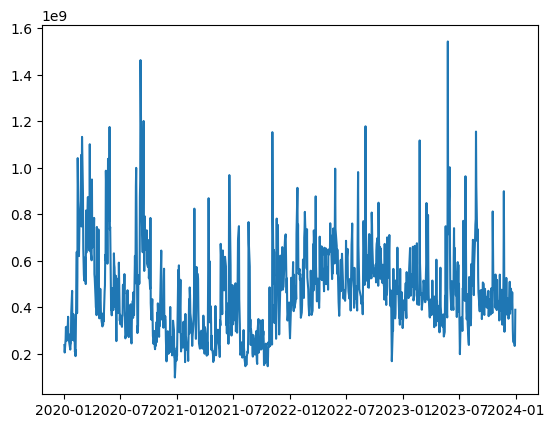

In [25]:
plt.plot(finance_data.index, finance_data['Volume'])